In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set")
assert DATA_ROOT.exists(), "Dataset folder not found"

In [ ]:
TRANSFORM_MAP = {
    "original.jpg": "original",
    "crop.jpg": "cropped",
    "blur.jpg": "blurred",
    "bright.jpg": "brightened",
    "contrast.jpg": "contrasted",
}

records = []

for folder in tqdm(sorted(os.listdir(DATA_ROOT))):
    folder_path = os.path.join(DATA_ROOT, folder)
    if not os.path.isdir(folder_path):
        continue

    group_id = folder  # img_00000

    for fname in os.listdir(folder_path):
        if fname not in TRANSFORM_MAP:
            continue

        transform = TRANSFORM_MAP[fname]
        is_original = int(transform == "original")

        records.append({
            "image_path": os.path.join(folder_path, fname),
            "group_id": group_id,
            "transform": transform,
            "is_original": is_original
        })

df = pd.DataFrame(records)

# one-hot labels
transform_types = sorted(df["transform"].unique())
for t in transform_types:
    df[t] = (df["transform"] == t).astype(int)

# save
df.to_csv("ndid_metadata.csv", index=False)

print(df.head())
print("Total images:", len(df))
print("Transforms:", transform_types)


100%|██████████| 4996/4996 [01:30<00:00, 55.41it/s] 


                                          image_path   group_id   transform  \
0  /content/drive/MyDrive/copydays-ndid/final/img...  img_00000     blurred   
1  /content/drive/MyDrive/copydays-ndid/final/img...  img_00000    original   
2  /content/drive/MyDrive/copydays-ndid/final/img...  img_00000     cropped   
3  /content/drive/MyDrive/copydays-ndid/final/img...  img_00000     resized   
4  /content/drive/MyDrive/copydays-ndid/final/img...  img_00000  contrasted   

   is_original  blurred  brightened  contrasted  cropped  original  resized  
0            0        1           0           0        0         0        0  
1            1        0           0           0        0         1        0  
2            0        0           0           0        1         0        0  
3            0        0           0           0        0         0        1  
4            0        0           0           1        0         0        0  
Total images: 29976
Transforms: ['blurred', 'brightened',

In [ ]:
image_paths = df["image_path"].values
print("Total images:", len(image_paths))
valid_images = []
corrupt_images = []

for img_path in tqdm(image_paths):
  try:
    img = Image.open(img_path)
    img.verify()
    valid_images.append(img_path)
  except:
    corrupt_images.append(img_path)


print("Valid images:", len(valid_images))
print("Corrupt images:", len(corrupt_images))

Total images: 29976


  2%|▏         | 584/29976 [02:57<2:26:36,  3.34it/s]

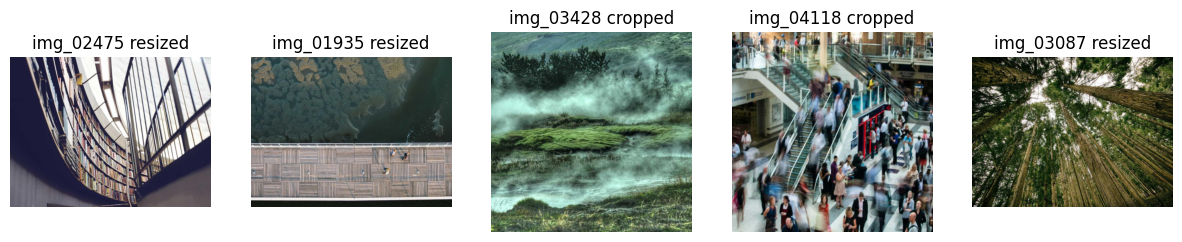

In [ ]:
import random



df = pd.read_csv('metadata.csv')
sample = df.sample(5)
plt.figure(figsize=(15, 3))


for i, row in enumerate(sample.itertuples()):
  img = Image.open(row.image_path)
  plt.subplot(1, 5, i+1)
  plt.imshow(img)
  plt.axis('off')
  plt.title(row.group_id + " " + row.transform)


plt.show()

In [ ]:
df.drop(df[df['transform']=='resized'].index,inplace=True,axis=0)
df.head()

,image_path,group_id,transform,is_original,blurred,brightened,contrasted,cropped,original
0,/content/drive/MyDrive/copydays-ndid/final/img...,img_00000,blurred,0,1,0,0,0,0
1,/content/drive/MyDrive/copydays-ndid/final/img...,img_00000,original,1,0,0,0,0,1
2,/content/drive/MyDrive/copydays-ndid/final/img...,img_00000,cropped,0,0,0,0,1,0
4,/content/drive/MyDrive/copydays-ndid/final/img...,img_00000,contrasted,0,0,0,1,0,0
5,/content/drive/MyDrive/copydays-ndid/final/img...,img_00000,brightened,0,0,1,0,0,0


In [ ]:
df.to_csv("metadata.csv", index=False)